# **PyTorch Workflow Exercise**

In [1]:
import torch

In [ ]:
# Setup device-agnostic code


## **Q1 Create a straight line dataset using the linear regression formula (`weight * X + bias`)**
  * Set `weight=0.4` and `bias=0.7` there should be at least 100 datapoints total.
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

Total points : 100
Training     : 80  (80%)
Testing      : 20  (20%)


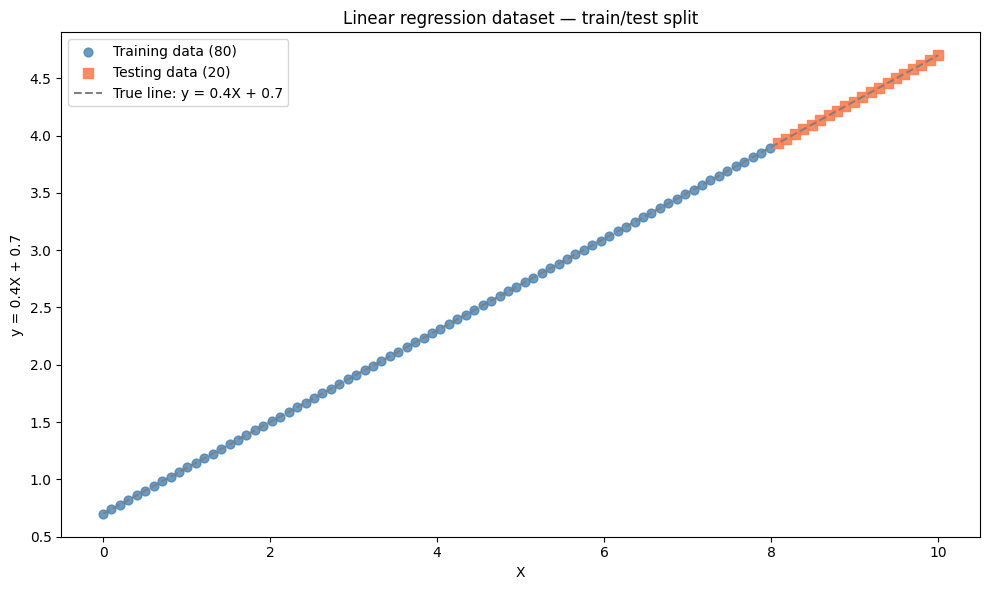

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
WEIGHT = 0.4
BIAS = 0.7
N = 100

# Generate dataset: y = weight * X + bias
X = np.linspace(0, 10, N)
y = WEIGHT * X + BIAS

# Train/test split (80/20, sequential)
split_idx = int(N * 0.8)  # 80

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Total points : {N}")
print(f"Training     : {len(X_train)}  ({len(X_train)/N*100:.0f}%)")
print(f"Testing      : {len(X_test)}  ({len(X_test)/N*100:.0f}%)")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_train, y_train, color='steelblue', label='Training data (80)', s=40, alpha=0.8)
ax.scatter(X_test,  y_test,  color='coral',     label='Testing data (20)',  s=50, marker='s', alpha=0.9)
ax.plot(X, y, color='gray', linestyle='--', linewidth=1.5, label='True line: y = 0.4X + 0.7')

ax.set_xlabel('X')
ax.set_ylabel('y = 0.4X + 0.7')
ax.set_title('Linear regression dataset — train/test split')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Create the split index (80% of total)
split_idx = int(len(X) * 0.8)  # → 80

# Split X
X_train = X[:split_idx]   # indices 0–79  (80 points)
X_test  = X[split_idx:]   # indices 80–99 (20 points)

# Split y
y_train = y[:split_idx]
y_test  = y[split_idx:]

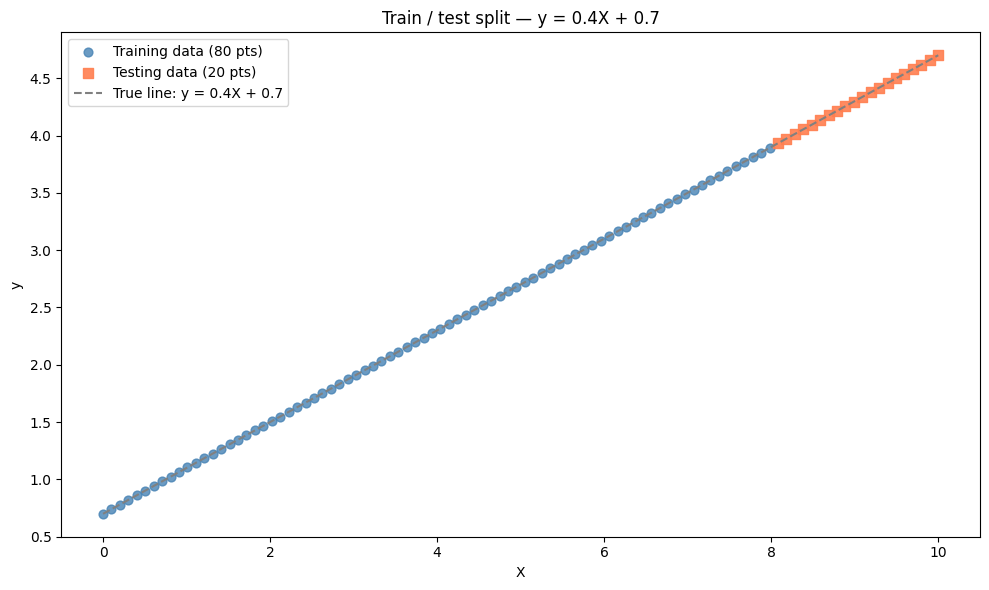

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train,
            color='steelblue', label=f'Training data ({len(X_train)} pts)',
            s=40, alpha=0.8)

plt.scatter(X_test, y_test,
            color='coral', label=f'Testing data ({len(X_test)} pts)',
            s=60, marker='s', alpha=0.9)

plt.plot(X, y,
         color='gray', linestyle='--', linewidth=1.5,
         label='True line: y = 0.4X + 0.7')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Train / test split — y = 0.4X + 0.7')
plt.legend()
plt.tight_layout()
plt.show()

## **Q2 Build a PyTorch model by subclassing `nn.Module`**
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in Q1
  * Once you've constructed the model, make an instance of it and check its `state_dict()`
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can

In [7]:
import torch
from torch import nn

# Set random seed for reproducibility
torch.manual_seed(42)

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Randomly initialized parameters (requires_grad=True by default for nn.Parameter)
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True))
        self.bias    = nn.Parameter(torch.randn(1, requires_grad=True))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias   # y = weight * X + bias

# Instantiate the model
model = LinearRegressionModel()

# Check state_dict
print(model.state_dict())

OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})


In [8]:
import torch
from torch import nn

# Set random seed for reproducibility
torch.manual_seed(42)

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Randomly initialized learnable parameters
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True))
        self.bias    = nn.Parameter(torch.randn(1, requires_grad=True))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # y = weight * X + bias  (same formula used in Q1)
        return self.weights * x + self.bias

# Instantiate the model
model = LinearRegressionModel()

# Check state_dict
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [9]:
# Set target device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Instantiate the model and send it to the target device
model = LinearRegressionModel().to(device)
print(model)
print(model.state_dict())

Using device: cuda
LinearRegressionModel()
OrderedDict({'weights': tensor([0.2345], device='cuda:0'), 'bias': tensor([0.2303], device='cuda:0')})


## **Q3 Write the training loop with `MSE` as the loss function and `Adam` as optimizer**.
  * Set the learning rate of the optimizer to be 0.05 and the parameters to optimize should be the `model.parameters()` from the model you created in Q2
  * Write a training loop to perform the appropriate training steps for 100 epochs
  * The training loop should test the model on the test dataset every 10 epochs

In [10]:
# Create the loss function and optimizer
# Loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

# Convert data to tensors and send to device
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)


In [11]:
# Send data to target device
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

# Train model for 300 epochs
epochs = 300

for epoch in range(epochs):

    ### Training
    # Put model in train mode
    model.train()

    # 1. Forward pass
    y_pred = model(X_train_t)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train_t)

    # 3. Zero gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        y_test_pred = model(X_test_t)
        test_loss   = loss_fn(y_test_pred, y_test_t)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 1.426 | Test loss: 2.148
Epoch: 10 | Train loss: 0.276 | Test loss: 1.084
Epoch: 20 | Train loss: 0.071 | Test loss: 0.129
Epoch: 30 | Train loss: 0.012 | Test loss: 0.102
Epoch: 40 | Train loss: 0.002 | Test loss: 0.000
Epoch: 50 | Train loss: 0.001 | Test loss: 0.004
Epoch: 60 | Train loss: 0.000 | Test loss: 0.000
Epoch: 70 | Train loss: 0.000 | Test loss: 0.000
Epoch: 80 | Train loss: 0.000 | Test loss: 0.000
Epoch: 90 | Train loss: 0.000 | Test loss: 0.000
Epoch: 100 | Train loss: 0.000 | Test loss: 0.000
Epoch: 110 | Train loss: 0.000 | Test loss: 0.000
Epoch: 120 | Train loss: 0.000 | Test loss: 0.000
Epoch: 130 | Train loss: 0.000 | Test loss: 0.000
Epoch: 140 | Train loss: 0.000 | Test loss: 0.000
Epoch: 150 | Train loss: 0.000 | Test loss: 0.000
Epoch: 160 | Train loss: 0.000 | Test loss: 0.000
Epoch: 170 | Train loss: 0.000 | Test loss: 0.000
Epoch: 180 | Train loss: 0.000 | Test loss: 0.000
Epoch: 190 | Train loss: 0.000 | Test loss: 0.000
Epoch: 200 

## **Q4 Make predictions with the trained model on the test data**
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

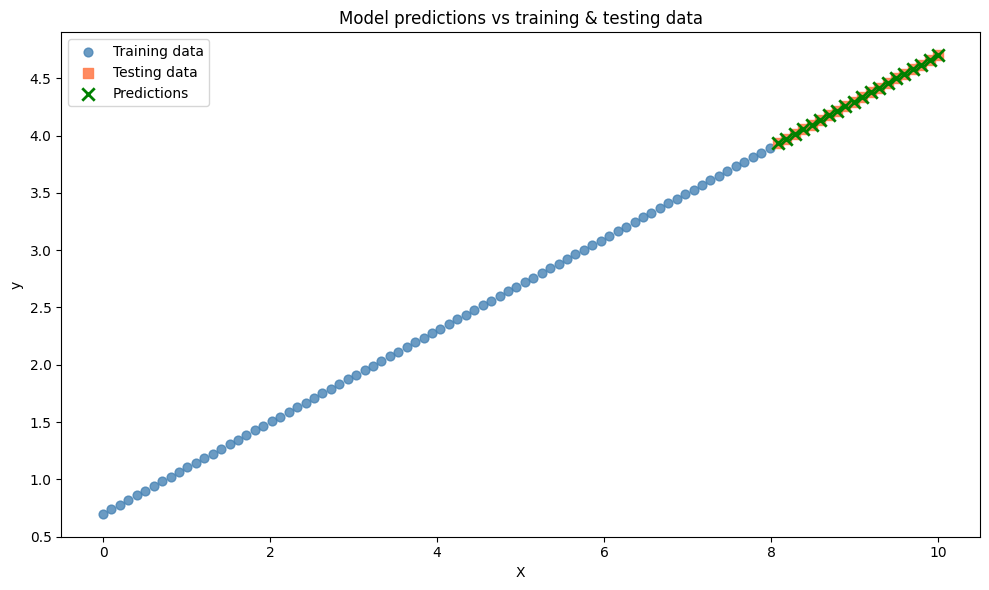

In [12]:
# Make predictions with the model
# Make predictions with the trained model on the test data
model.eval()
with torch.inference_mode():
    y_preds = model(X_test_t).cpu().numpy()  # move off GPU → numpy for plotting

# Plot predictions against training and testing data
plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train,
            color='steelblue', s=40, alpha=0.8, label='Training data')

plt.scatter(X_test, y_test,
            color='coral', s=60, marker='s', alpha=0.9, label='Testing data')

plt.scatter(X_test, y_preds,
            color='green', s=80, marker='x', linewidths=2, label='Predictions')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Model predictions vs training & testing data')
plt.legend()
plt.tight_layout()
plt.show()


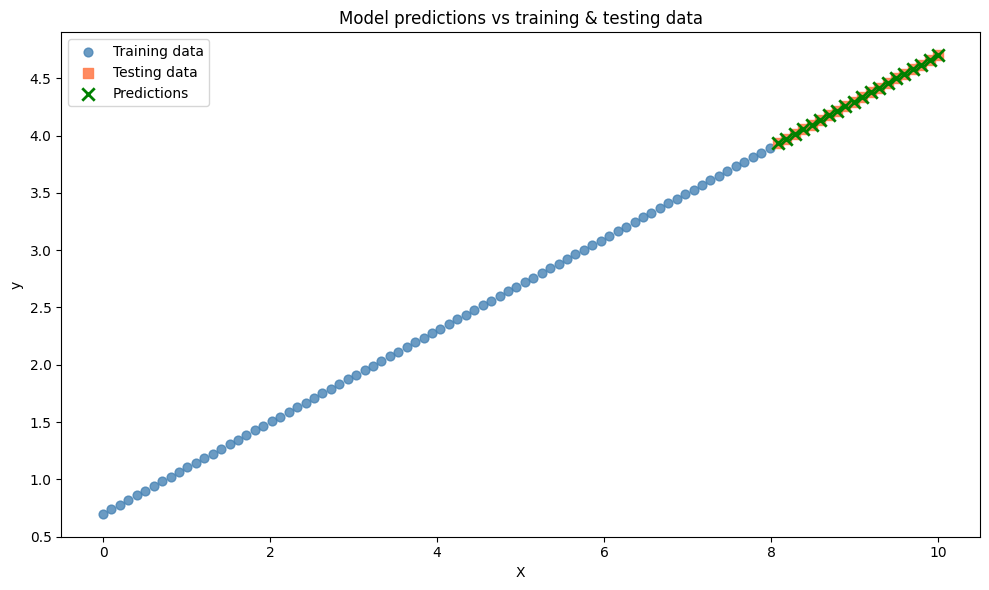

In [13]:
# Plot the predictions (these may need to be on a specific device)
# Plot the predictions (these may need to be on a specific device)
model.eval()
with torch.inference_mode():
    y_preds = model(X_test_t).cpu().numpy()

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train,
            color='steelblue', s=40, alpha=0.8, label='Training data')

plt.scatter(X_test, y_test,
            color='coral', s=60, marker='s', alpha=0.9, label='Testing data')

plt.scatter(X_test, y_preds,
            color='green', s=80, marker='x', linewidths=2, label='Predictions')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Model predictions vs training & testing data')
plt.legend()
plt.tight_layout()
plt.show()


## **Q5 Save your trained model's `state_dict()` to file**
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [14]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "q5_linear_regression_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 2. Create model save path
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

# 3. Save the model state dict
loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model.to(device)
print(f"\nLoaded model state_dict:\n{loaded_model.state_dict()}")

# 4. Make predictions with the loaded model
loaded_model.eval()
with torch.inference_mode():
    y_preds_loaded = loaded_model(X_test_t).cpu().numpy()

# 5. Confirm predictions match the original
print(f"\nOriginal predictions:\n{y_preds}")
print(f"\nLoaded model predictions:\n{y_preds_loaded}")
print(f"\nPredictions match: {(y_preds == y_preds_loaded).all()}")


Model saved to: models/q5_linear_regression_model.pth

Loaded model state_dict:
OrderedDict({'weights': tensor([0.4000], device='cuda:0'), 'bias': tensor([0.7000], device='cuda:0')})

Original predictions:
[3.9323232 3.9727273 4.013131  4.0535355 4.0939393 4.134343  4.1747475
 4.215152  4.2555556 4.2959595 4.336364  4.3767676 4.417172  4.457576
 4.4979796 4.538384  4.578788  4.6191916 4.659596  4.7      ]

Loaded model predictions:
[3.9323232 3.9727273 4.013131  4.0535355 4.0939393 4.134343  4.1747475
 4.215152  4.2555556 4.2959595 4.336364  4.3767676 4.417172  4.457576
 4.4979796 4.538384  4.578788  4.6191916 4.659596  4.7      ]

Predictions match: True


In [15]:
# Create new instance of model and load saved state dict (make sure to put it on the target device)

# Create new instance of model and load saved state dict (make sure to put it on the target device)
loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model.to(device)

print(f"Loaded model state_dict:\n{loaded_model.state_dict()}")


Loaded model state_dict:
OrderedDict({'weights': tensor([0.4000], device='cuda:0'), 'bias': tensor([0.7000], device='cuda:0')})


In [16]:
# Make predictions with loaded model and compare them to the previous
# Make predictions with loaded model and compare them to the previous
loaded_model.eval()
with torch.inference_mode():
    y_preds_loaded = loaded_model(X_test_t).cpu().numpy()

# Compare predictions
print(f"Original predictions:\n{y_preds}\n")
print(f"Loaded model predictions:\n{y_preds_loaded}\n")
print(f"Predictions match: {(y_preds == y_preds_loaded).all()}")


Original predictions:
[3.9323232 3.9727273 4.013131  4.0535355 4.0939393 4.134343  4.1747475
 4.215152  4.2555556 4.2959595 4.336364  4.3767676 4.417172  4.457576
 4.4979796 4.538384  4.578788  4.6191916 4.659596  4.7      ]

Loaded model predictions:
[3.9323232 3.9727273 4.013131  4.0535355 4.0939393 4.134343  4.1747475
 4.215152  4.2555556 4.2959595 4.336364  4.3767676 4.417172  4.457576
 4.4979796 4.538384  4.578788  4.6191916 4.659596  4.7      ]

Predictions match: True
